In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import math
import os
import glob 
from collections import defaultdict
import re

On boucle sur les transects

In [3]:
prov_folder = sorted(glob.glob("/data/rd_exchange/salbernhe/provinces/netcdf_monthly_provinces/provinces_Y*_M*.nc"))

PATH_prov = Path("/data/rd_exchange/salbernhe/provinces/netcdf_monthly_provinces/provinces_Y1998_M01.nc")
ds_prov = xr.open_dataset(PATH_prov)
ds_prov

<xarray.Dataset> Size: 35MB
Dimensions:    (latitude: 2040, longitude: 4320)
Coordinates:
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.75 89.83 89.92
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    province   (latitude, longitude) float32 35MB ...
Attributes:
    title:        Regions biome T, Str, npp (from GLORYS/VGPM)
    institution:  CLS
    references:   http://www.cls.fr

In [4]:
PATH_sv = Path("/data/rd_exchange/salbernhe/data/acoustics/profiles38kHz10t0750m20251006.nc")
ds_sv = xr.open_dataset(PATH_sv)
ds_sv

<xarray.Dataset> Size: 351MB
Dimensions:     (file_index: 318, time: 541061, range: 75)
Coordinates:
  * file_index  (file_index) int64 3kB 1 2 3 4 5 6 7 ... 313 314 315 316 317 318
  * time        (time) datetime64[ns] 4MB 2008-04-09T10:00:34.000003072 ... 2...
  * range       (range) int64 600B 10 20 30 40 50 60 ... 700 710 720 730 740 750
Data variables:
    file_label  (file_index) <U116 148kB ...
    longitude   (time) float64 4MB ...
    latitude    (time) float64 4MB ...
    file        (time) int64 4MB ...
    interval    (time) float64 4MB ...
    sunangle    (time) float64 4MB ...
    Sv          (range, time) float64 325MB ...
    frequency   |S1 1B ...

In [ ]:
print(ds_sv['file_label'].sel(file_index=3).item())
##A regarder, les dates n'ont pas toute le même format: regarder avec datetime

BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AtlanticOcean_2014-10-03T14Z_2014-10-17T23Z.nc


In [5]:
#fonction pour passer de db à linéaire et vice-versa

def db_to_lin(x):
    return 10.0 ** (x / 10.0)

def lin_to_db(x):
    return 10.0 * np.log10(x)


end_dawn = 6      # au-dessus de +6°: jour
end_dusk = -6    #en dessous de -6°: nuit


In [6]:

rows_day = []
rows_night=[]
def process_segment(ds_segment, province, file_idx): #calcule les moyennes d'un transect jour/nuit d'un segment et alimente row[]

    ds_sv_lin = db_to_lin(ds_segment["Sv"])

    is_day = ds_segment["sunangle"] > end_dawn
    is_night = ds_segment["sunangle"]< end_dusk

    range = ds_segment["range"].values

    if is_day.sum()>0: #On fait la somme des Trues(1) et des Falses(0) des booléens pour vérifier qu'on a bien des valeurs pour le jour
        sv_day = lin_to_db(ds_sv_lin.isel(time=is_day).mean(dim="time", skipna=True)).values

        for r, sv_val in zip(range, sv_day):
            rows_day.append({"file_idx": file_idx, "province": province, "range": r, "sv": sv_val})

    if is_night.sum() > 0: #idem, on vérifie qu'on a bien des valeurs pour la nuit. 
        sv_night = lin_to_db(ds_sv_lin.isel(time=is_night).mean(dim="time", skipna=True)).values

        for r, sv_val in zip(range, sv_night):
            rows_night.append({"file_idx": file_idx,"province": province, "range": r, "sv": sv_val})



for file_idx_da in ds_sv["file_index"]: #on boucle sur les index du ds_sv

    file_idx = file_idx_da.item() #pour passer d'un array à juste un int Python, mais à enlever plus tard si la ligne est inutile
    file_label = ds_sv["file_label"].sel(file_index=file_idx).item() #.item() parce que sinon renvoie un dataArray 0-dimensionnel, et pas juste une sttring comme je veux
    mask1 = ds_sv["file"] == file_idx
    times_file = ds_sv["time"].where(mask1, drop=True).values

    if len(times_file) == 0:
        print(f"Aucun ping trouvé pour file_idx {file_idx} ({file_label})")
        continue

    months = pd.to_datetime(times_file).to_period("M")
    mois_dominant = months.value_counts().idxmax()
    year = str(mois_dominant.year)
    month = f"{mois_dominant.month:02d}"

    wanted_file_name = f"provinces_Y{year}_M{month}.nc"
    matching_file_prov = None
    for file_prov in prov_folder: 
        if os.path.basename(file_prov)== wanted_file_name:
            matching_file_prov = file_prov
            break

    if matching_file_prov is None:
        print(f"Aucune correspondance trouvée pour {file_prov} ")
        continue
    
    #On a donc la correspondance entre date du transect et date des provinces. Maintenant on cherche à associer chaque partie du transect à la province qu'il traverse (via un mask)

    ds_prov = xr.open_dataset(matching_file_prov)
    
    mask = ds_sv["file"] == file_idx # tableau bouléen qui parcours tous les pings, et affiche True si le ping appartient au fichier qu'on traite actuellement. 
    ds_file = ds_sv.where(mask,drop=True)
    lat_ping = ds_sv["latitude"].where(mask, drop=True)
    lon_ping = ds_sv["longitude"].where(mask, drop=True)
    
    list_prov_with_NaN = ds_prov["province"].sel(latitude=xr.DataArray(lat_ping.values, dims="time"), longitude= xr.DataArray(lon_ping.values, dims="time"), method="nearest").values
    list_prov = np.unique(list_prov_with_NaN[~np.isnan(list_prov_with_NaN)]) #liste propre des provinces sans les Nans




#cas 1. le transect ne traverse qu'une province
    if len(list_prov) == 1:
        province = list_prov[0]
        process_segment(ds_file, province, file_idx)

#Cas 2. Le transect traverse plusieurs provinces

    else:
        idx_change_points = np.where(np.diff(list_prov_with_NaN) != 0)[0] +1 #contient les indices où la province change
        segments_idx = np.split(np.arange(len(list_prov_with_NaN)), idx_change_points) 

        indices_par_province = {} #{1: [0,1,4,5], 2: [2,3]} → un seul appel à process_segment pour la province 1, qui va moyenner tous les pings des deux passages ensemble avant de calculer le profil jour/nuit

        for seg in segments_idx:
            list_prov_seg = list_prov_with_NaN[seg[0]]
            prov_val = list_prov_with_NaN[seg[0]]
            if np.isnan(prov_val):
                continue  # segment hors grille, ignoré
            indices_par_province.setdefault(prov_val, []).extend(seg.tolist()) 

        
        for prov_val, indices in indices_par_province.items():
            indices_sorted = np.sort(np.array(indices))  # remet dans l'ordre temporel
            ds_segment = ds_file.isel(time=indices_sorted)
            process_segment(ds_segment, prov_val, file_idx) 
            
            
           
    ds_prov.close()


df_day = pd.DataFrame(rows_day)
df_night = pd.DataFrame(rows_night)   

In [16]:
doublons = df_day.groupby(["province", "file_idx", "range"]).size()
doublons_suspects = doublons[doublons > 1]
print(doublons_suspects)
print(len(doublons_suspects))

Series([], dtype: int64)
0


In [21]:
#print(ds_sv["sunangle"].min().item(), ds_sv["sunangle"].max().item())
print(df_day[df_day["province"]==601.0])
print(df_day[df_day["province"] == 601.0]["sv"])

       file_idx  province  range         sv
0             1     601.0     10 -94.461165
1             1     601.0     20 -99.064236
2             1     601.0     30 -97.429924
3             1     601.0     40 -87.716301
4             1     601.0     50 -83.790791
...         ...       ...    ...        ...
47470       314     601.0    710 -74.586428
47471       314     601.0    720 -74.324016
47472       314     601.0    730 -74.055786
47473       314     601.0    740 -74.077662
47474       314     601.0    750 -74.073272

[3450 rows x 4 columns]
0       -94.461165
1       -99.064236
2       -97.429924
3       -87.716301
4       -83.790791
           ...    
47470   -74.586428
47471   -74.324016
47472   -74.055786
47473   -74.077662
47474   -74.073272
Name: sv, Length: 3450, dtype: float64


In [17]:
df_day

,file_idx,province,range,sv
0,1,601.0,10,-94.461165
1,1,601.0,20,-99.064236
2,1,601.0,30,-97.429924
3,1,601.0,40,-87.716301
4,1,601.0,50,-83.790791
...,...,...,...,...
47920,318,102.0,710,-72.348991
47921,318,102.0,720,-72.614772
47922,318,102.0,730,-72.682960
47923,318,102.0,740,-72.815894


## Test

Fichier 100 : 1879 pings
  IMOS_SOOP-BA_AE_20100227T022510Z_VHGI_FV02_Southern-Champion-ES60-38_END-20100303T031558Z_C-20160222T052949Z.nc


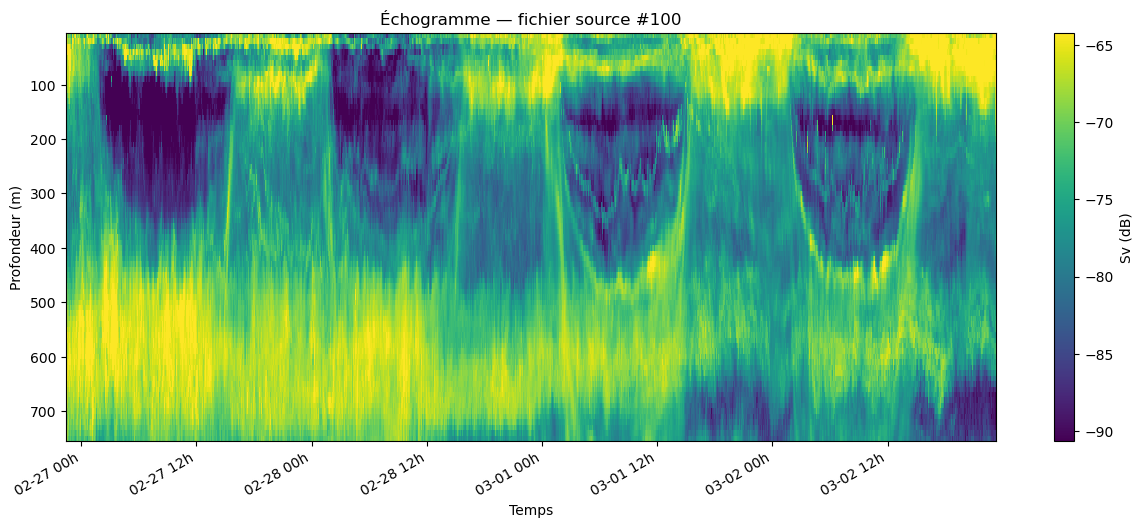

In [28]:
sv = ds_sv.Sv.values
rng = ds_sv.range.values
file_ids, file_counts = np.unique(ds_sv.file.values, return_counts=True)
best_file = file_ids[99]
sel = np.where(ds_sv.file.values == best_file)[0]
i0, i1 = sel.min(), sel.max() + 1
label = ds_sv.file_label.sel(file_index=best_file).item()
print(f"Fichier {best_file} : {i1 - i0} pings\n  {label}")

seg = sv[:, i0:i1]
seg_t = pd.to_datetime(ds_sv.time.values[i0:i1])

fig, ax = plt.subplots(figsize=(15, 6))
pcm = ax.pcolormesh(seg_t, rng, seg, cmap="viridis",
                    vmin=np.nanpercentile(seg, 2), vmax=np.nanpercentile(seg, 98))
ax.invert_yaxis()
ax.set_xlabel("Temps"); ax.set_ylabel("Profondeur (m)")
ax.set_title(f"Échogramme — fichier source #{best_file}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
fig.autofmt_xdate()
plt.colorbar(pcm, ax=ax, label="Sv (dB)")
plt.show()

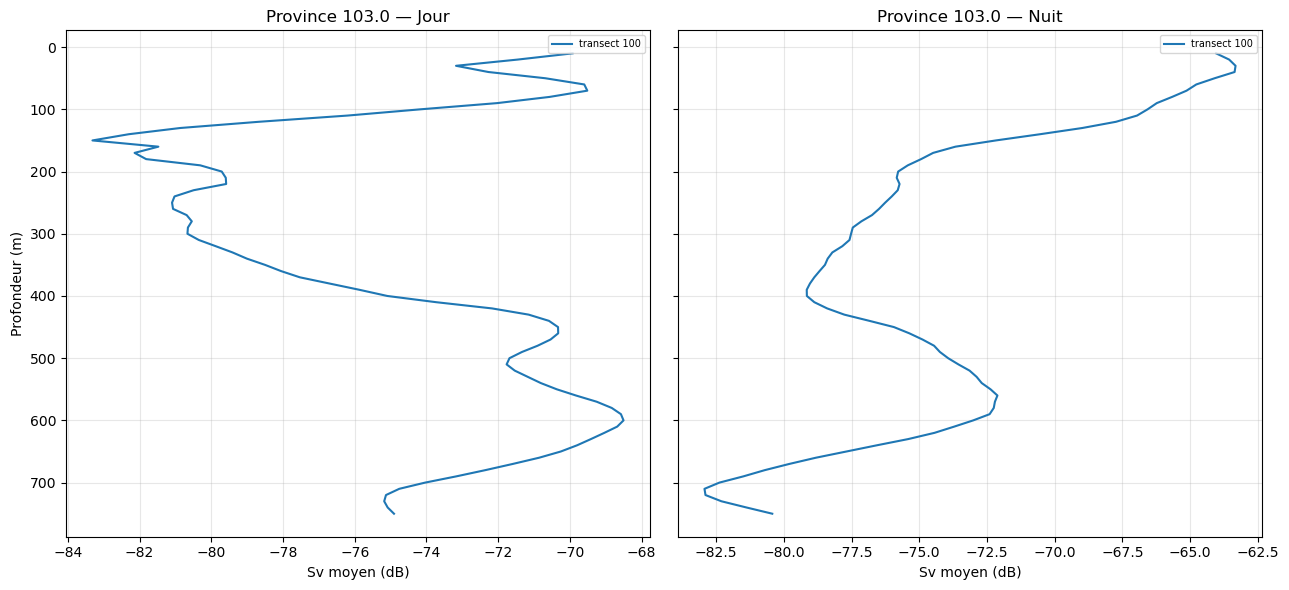

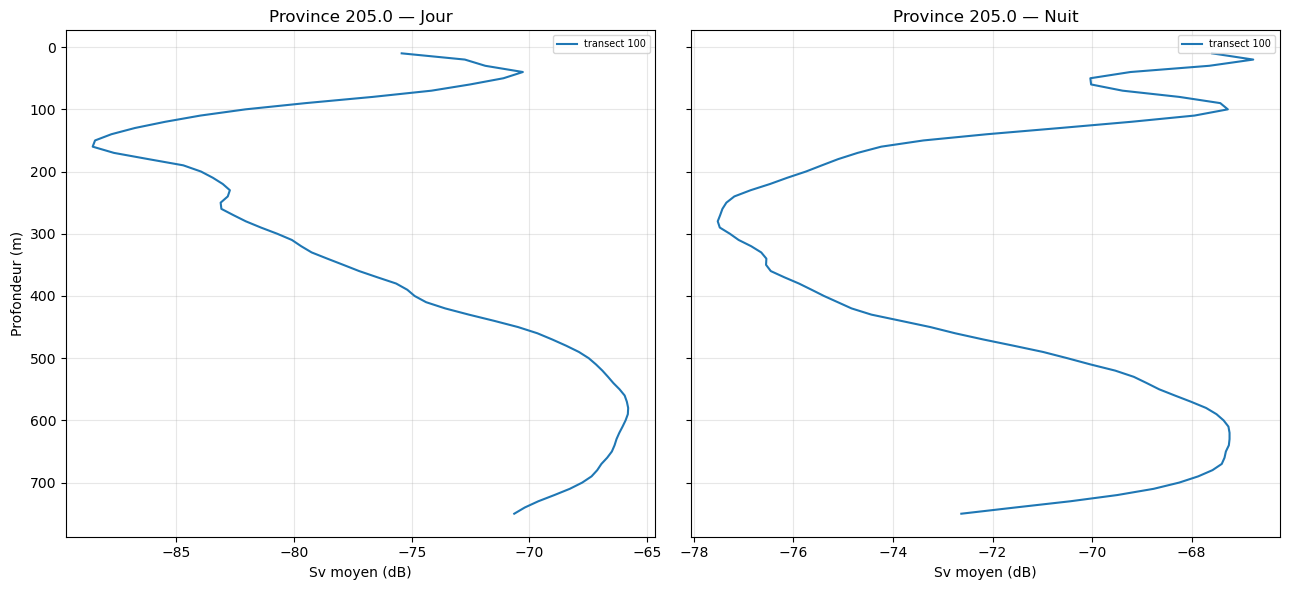

In [29]:
all_provinces = sorted(set(df_day["province"].unique()) | set(df_night["province"].unique()))
wanted_file = 100

for province in all_provinces:

    day_prov = df_day[df_day["province"] == province]
    night_prov = df_night[df_night["province"] == province]

    # On vérifie si le fichier voulu existe dans cette province (jour ou nuit)
    has_day = wanted_file in day_prov["file_idx"].values
    has_night = wanted_file in night_prov["file_idx"].values

    if not (has_day or has_night):
        continue  # on saute cette province sans rien afficher

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

    # --- Jour ---
    if has_day:
        group = day_prov[day_prov["file_idx"] == wanted_file].sort_values("range")
        axes[0].plot(group["sv"], group["range"], label=f"transect {wanted_file}")

    axes[0].set_xlabel("Sv moyen (dB)")
    axes[0].set_ylabel("Profondeur (m)")
    axes[0].set_title(f"Province {province} — Jour")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=7)

    # --- Nuit ---
    if has_night:
        group = night_prov[night_prov["file_idx"] == wanted_file].sort_values("range")
        axes[1].plot(group["sv"], group["range"], label=f"transect {wanted_file}")

    axes[1].set_xlabel("Sv moyen (dB)")
    axes[1].set_title(f"Province {province} — Nuit")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=7)

    axes[0].invert_yaxis()

    plt.tight_layout()
    plt.show()


In [31]:
# nom de fichier associé à best_file dans ds_sv
label_best = ds_sv.file_label.sel(file_index=best_file).item()

# nom de fichier associé à wanted_file - 1 dans ds_sv 
label_hypothese = ds_sv.file_label.sel(file_index=wanted_file).item()

print("label_best        :", label_best)
print("label hypothèse +1:", label_hypothese)
print("same ? :", label_best == label_hypothese)

label_best        : IMOS_SOOP-BA_AE_20100227T022510Z_VHGI_FV02_Southern-Champion-ES60-38_END-20100303T031558Z_C-20160222T052949Z.nc
label hypothèse +1: IMOS_SOOP-BA_AE_20100227T022510Z_VHGI_FV02_Southern-Champion-ES60-38_END-20100303T031558Z_C-20160222T052949Z.nc
same ? : True


In [ ]:
idx = ds_sv['file'][0].values     
nom_fichier = ds_sv['file_label'][idx].values   # renvoie le nom du fichier correspondant
print(idx, nom_fichier)

1 BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AtlanticOcean_2014-09-27T16Z_2014-10-01T10Z.nc


Pour une province choisie

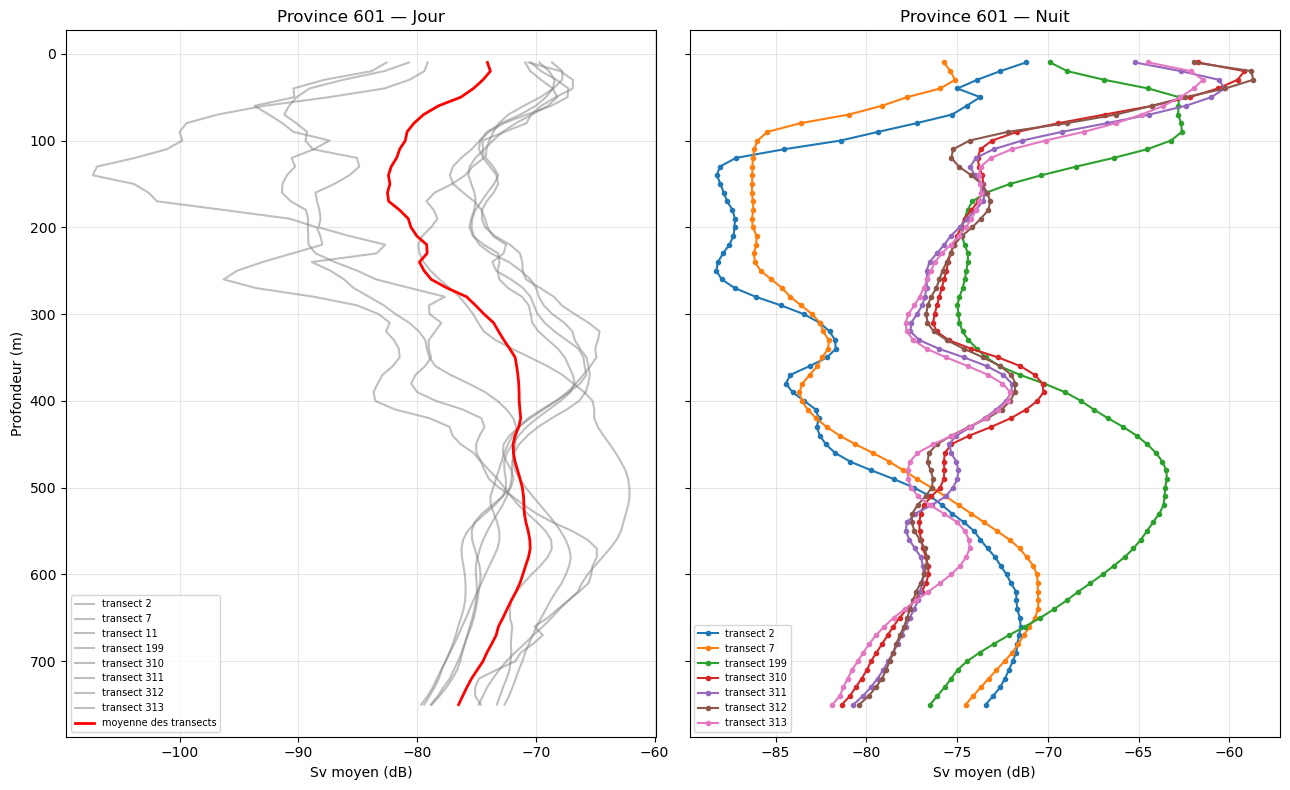

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)

# Filtrage sur la province 601
day_prov = df_day[df_day["province"] == 402.0]
night_prov = df_night[df_night["province"] == 402.0]

#Un courbe par transect de jour
moy_dico = defaultdict(list)
for file_idx, group in day_prov.groupby("file_idx"):
    group_sorted = group.sort_values("range")
   
    axes[0].plot(group_sorted["sv"], group_sorted["range"],color = "gray" , alpha= 0.5,label=f"transect {file_idx}")
    for r, s in zip(group_sorted["range"], group_sorted["sv"]):
        moy_dico[r].append(s)


ranges_sorted = sorted(moy_dico.keys())
sv_mean = [np.mean(moy_dico[r]) for r in ranges_sorted]

axes[0].plot(sv_mean, ranges_sorted, color="red", linewidth=2, label="moyenne des transects")
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Sv moyen (dB)")
axes[0].set_ylabel("Profondeur (m)")
axes[0].set_title("Province 601 — Jour")
axes[0].legend(fontsize=7)

#Une courbe par transect de nuit
for file_idx, group in night_prov.groupby("file_idx"):
    group_sorted = group.sort_values("range")
    axes[1].plot(group_sorted["sv"], group_sorted["range"],"-o", ms=3, label=f"transect {file_idx}")


axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Sv moyen (dB)")
axes[1].set_title("Province 601 — Nuit")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Pour toutes les provinces ┌( ಠ_ಠ)┘

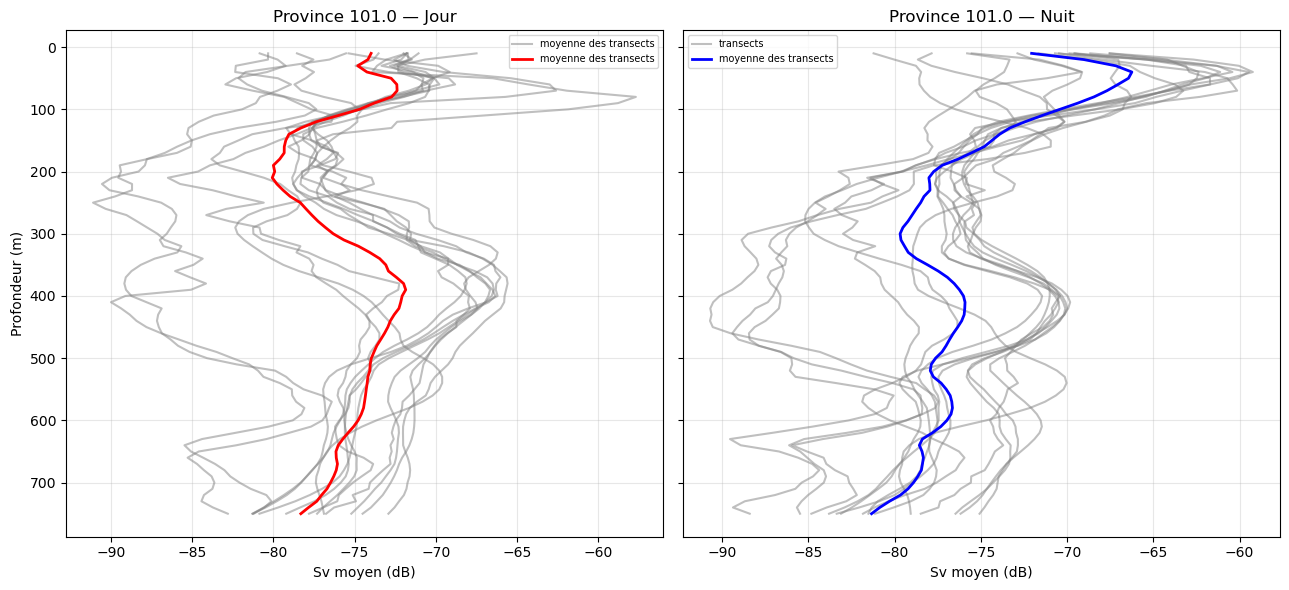

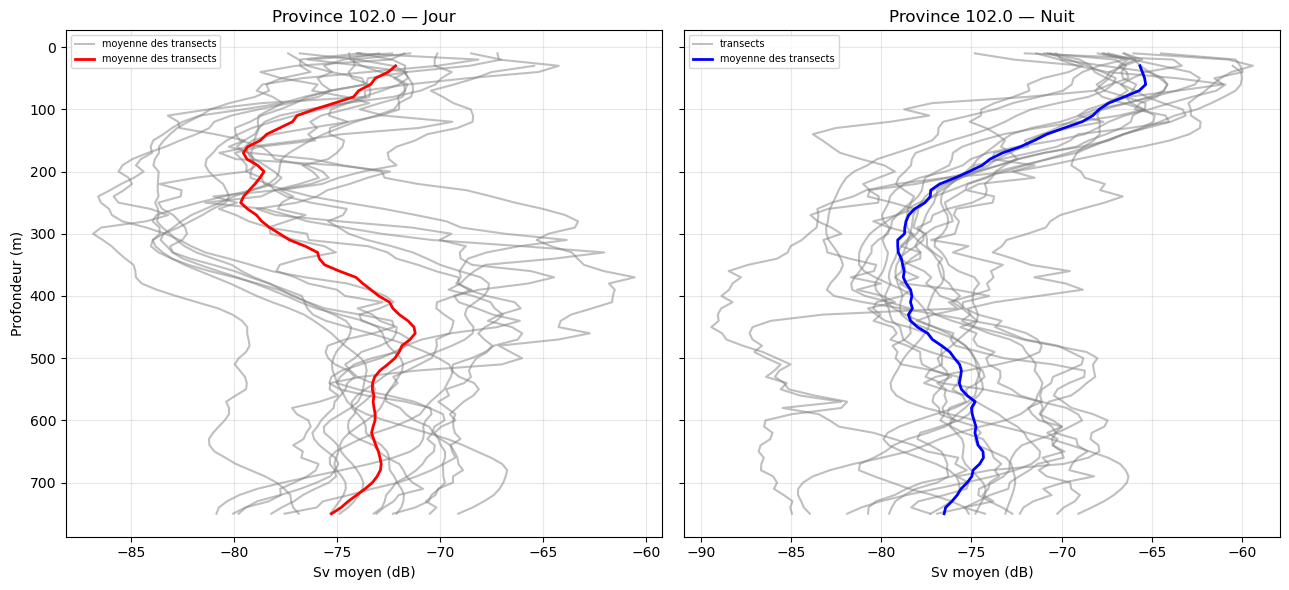

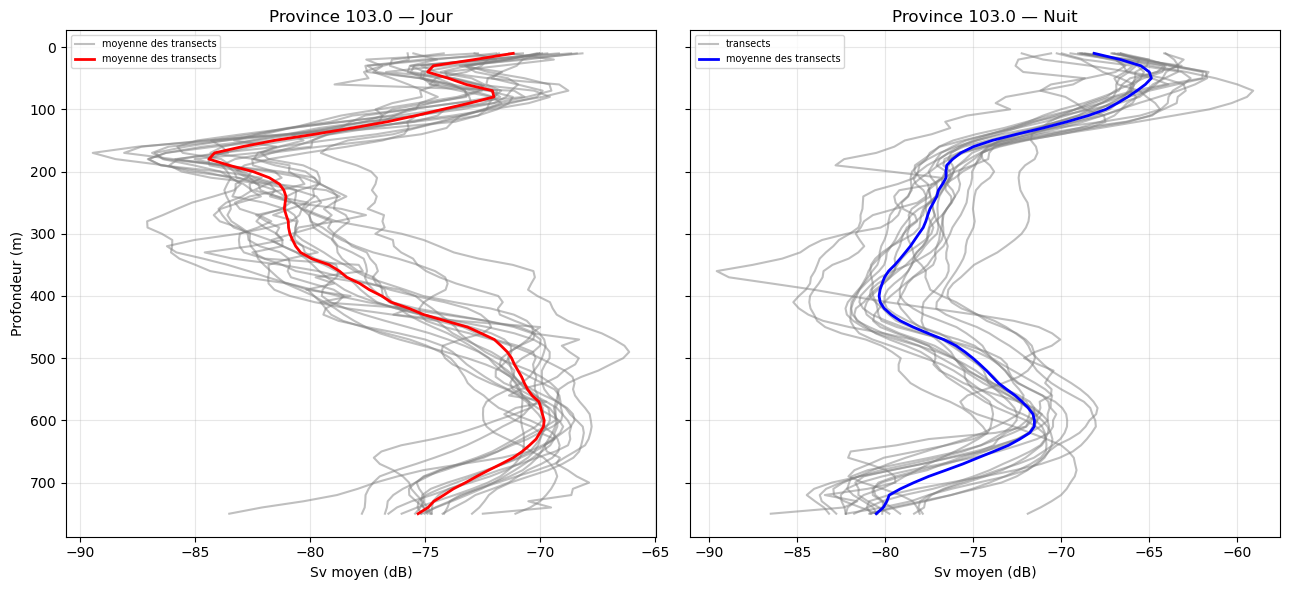

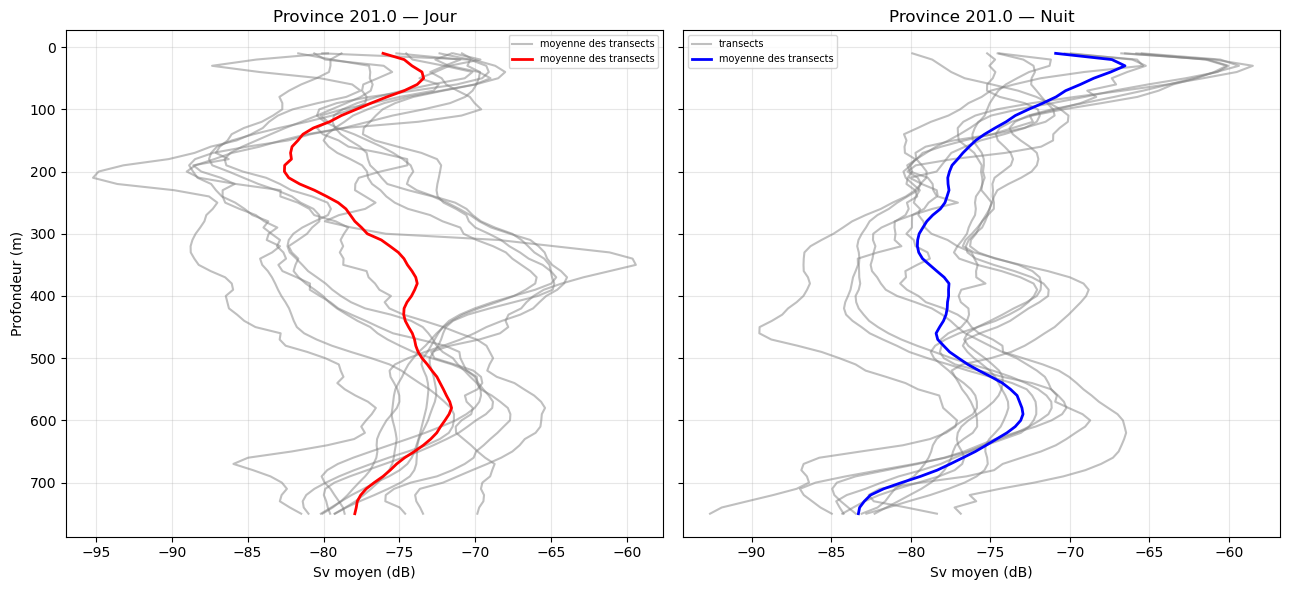

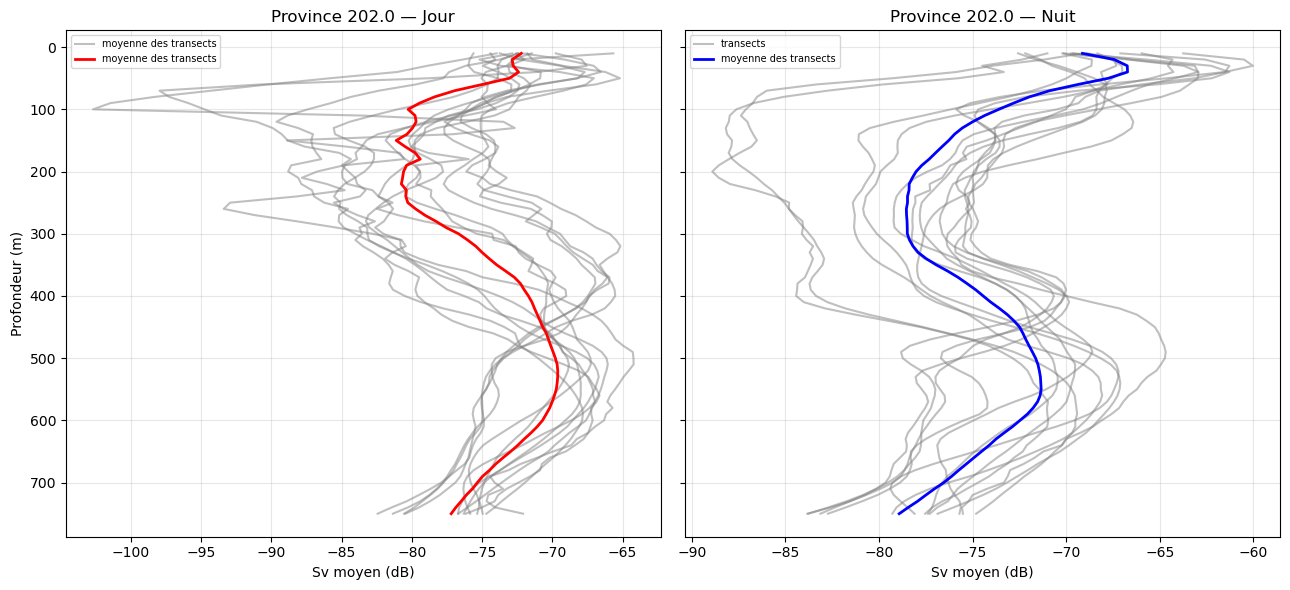

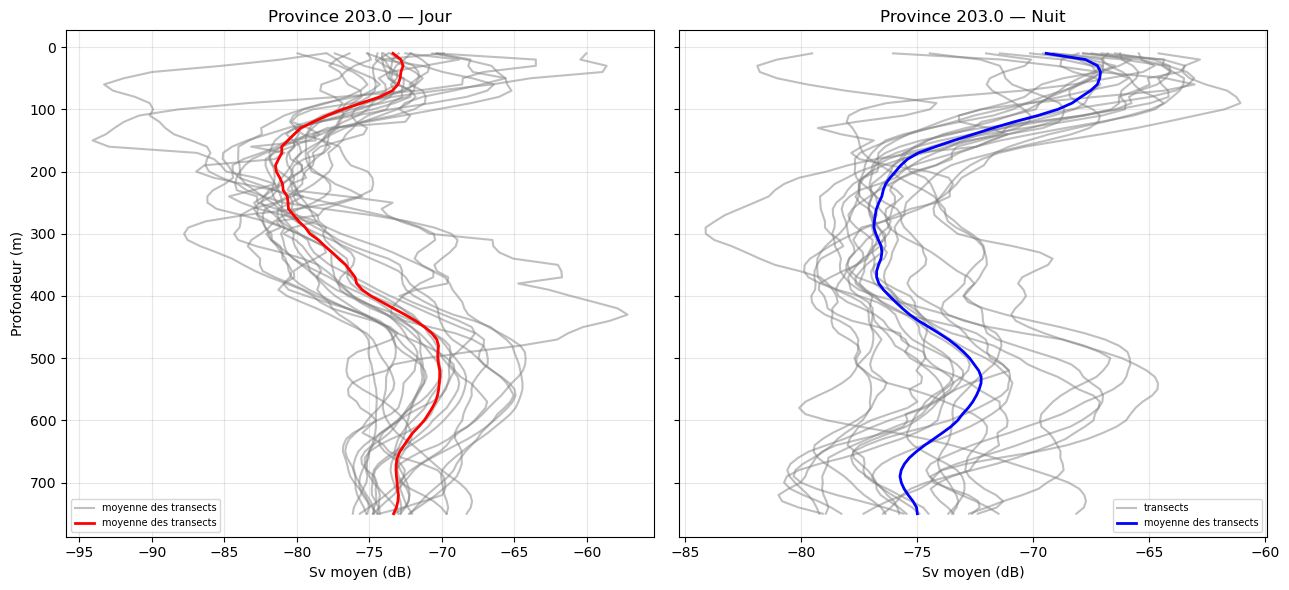

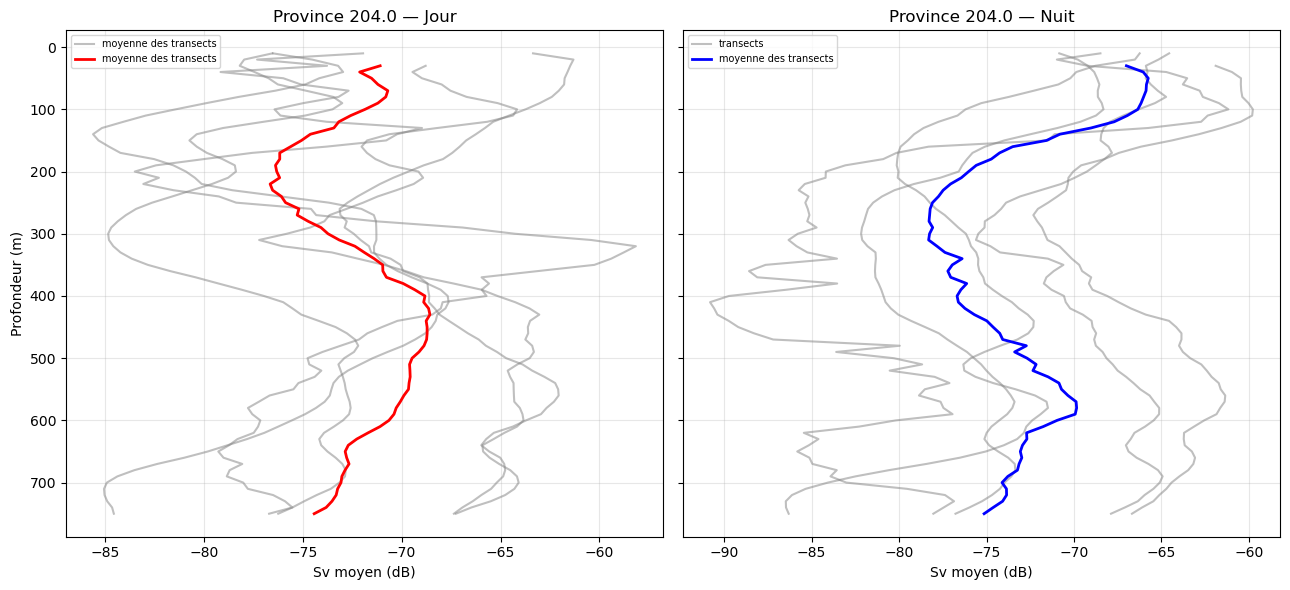

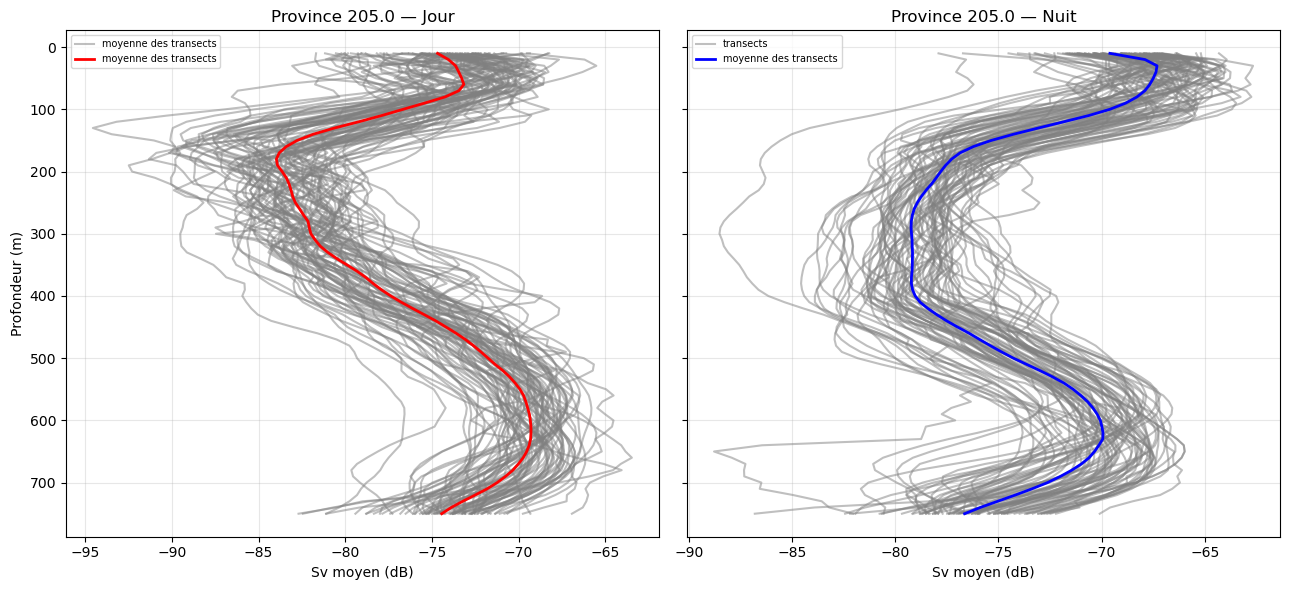

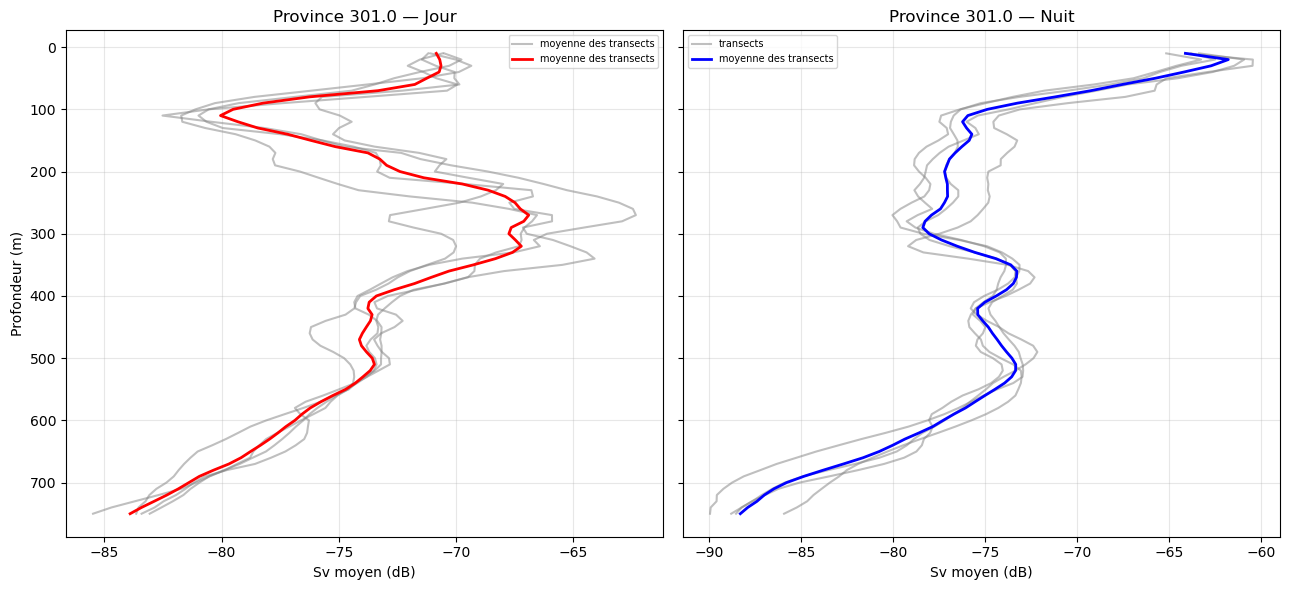

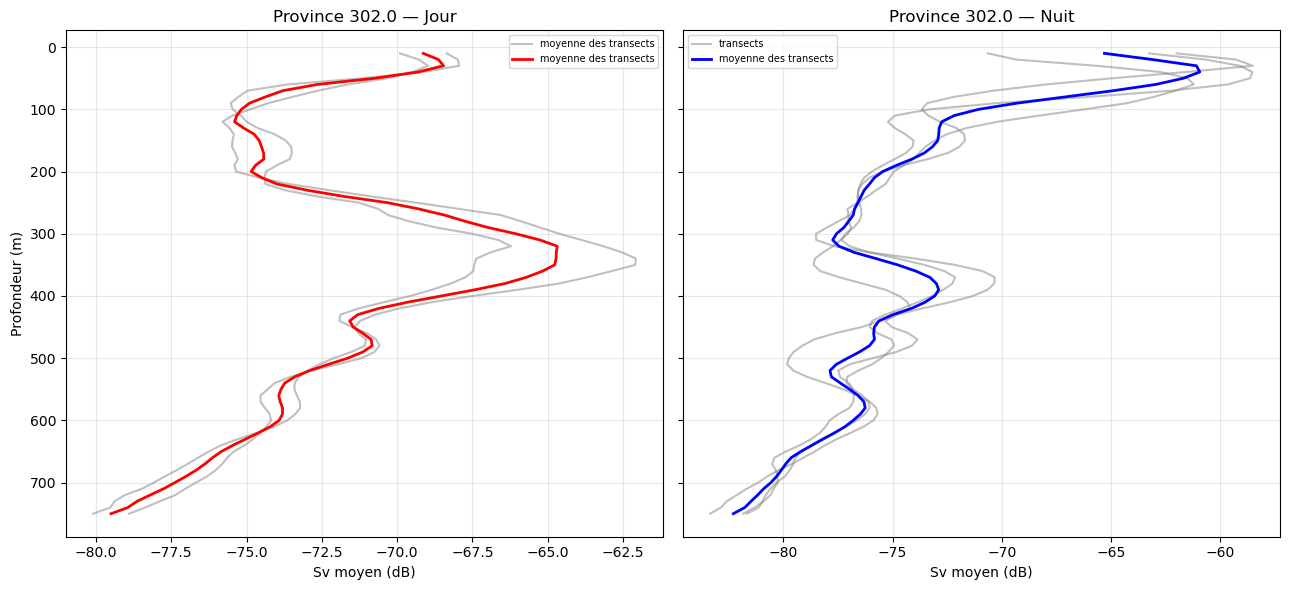

In [ ]:
all_provinces = sorted(set(df_day["province"].unique()) | set(df_night["province"].unique()))

for province in all_provinces:

    day_prov = df_day[df_day["province"] == province]
    night_prov = df_night[df_night["province"] == province]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

    # --- Jour ---
    moy_dico_day = defaultdict(list)
    for j, (file_idx, group) in enumerate(day_prov.groupby("file_idx")):
        group_sorted = group.sort_values("range")
        group.groupby("range").size().value_counts()
        axes[0].plot(group_sorted["sv"], group_sorted["range"], color ='gray', alpha = 0.5, label = "moyenne des transects" if j == 0 else None)
        for r, s in zip(group_sorted["range"], group_sorted["sv"]):
                        moy_dico_day[r].append(s)
  
    
    ranges_sorted_day = sorted(moy_dico_day.keys())
    sv_mean_day = [np.mean(moy_dico_day[r]) for r in ranges_sorted_day]

    axes[0].plot(sv_mean_day, ranges_sorted_day, color="red", linewidth=2, label="moyenne des transects")
    axes[0].set_xlabel("Sv moyen (dB)")
    axes[0].set_ylabel("Profondeur (m)")
    axes[0].set_title(f"Province {province} — Jour")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=7)

    # --- Nuit ---
    moy_dico_night= defaultdict(list)
    for i, (file_idx, group) in enumerate(night_prov.groupby("file_idx")):
        group_sorted = group.sort_values("range")
        axes[1].plot(group_sorted["sv"], group_sorted["range"], color ='gray', alpha = 0.5, label = "transects" if i == 0 else None )# label=f"transect {file_idx}

        for t, v in zip(group_sorted["range"], group_sorted["sv"]):
                                moy_dico_night[t].append(v)

    ranges_sorted_night = sorted(moy_dico_night.keys())
    sv_mean_night = [np.mean(moy_dico_night[r]) for r in ranges_sorted_night]

    axes[1].plot(sv_mean_night, ranges_sorted_night, color="blue", linewidth=2, label="moyenne des transects")   
    axes[1].set_xlabel("Sv moyen (dB)")
    axes[1].set_title(f"Province {province} — Nuit")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=7)

    axes[0].invert_yaxis()

    plt.tight_layout()
    plt.show()

In [46]:
doublons = df_day.groupby(["province", "file_idx", "range"]).size()
doublons_suspects = doublons[doublons > 1]
print(doublons_suspects)

province  file_idx  range
101.0     3         10       4
                    20       4
                    30       4
                    40       4
                    50       4
                            ..
601.0     314       710      2
                    720      2
                    730      2
                    740      2
                    750      2
Length: 46650, dtype: int64
